In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv('../data/telco_churn.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Handle Missing Values

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


Drop Irrelevant Column

In [6]:
# customerID is just an identifier — carries no predictive value
df.drop(columns=['customerID'], inplace=True)
print("Shape after dropping customerID:", df.shape)


Shape after dropping customerID: (7043, 20)


Engineer New Features

In [7]:
# Feature 1: Tenure Group (bucket continuous tenure into lifecycle stages)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr']
)

# Feature 2: Charge Ratio (monthly charges relative to total — detects recent price increases)
df['charge_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# Feature 3: Service Score (how many add-on services does the customer have?)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['service_score'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

print("New features added. Shape:", df.shape)
print("\nTenure Group distribution:\n", df['tenure_group'].value_counts())
print("\nService Score distribution:\n", df['service_score'].value_counts().sort_index())


New features added. Shape: (7043, 23)

Tenure Group distribution:
 tenure_group
0-1yr    2175
2-4yr    1594
5-6yr    1407
1-2yr    1024
4-5yr     832
Name: count, dtype: int64

Service Score distribution:
 service_score
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


Visualize New Features

C:\Users\Jagmohan\AppData\Local\Temp\ipykernel_16592\3163477396.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='charge_ratio', ax=axes[1], palette='Set2')


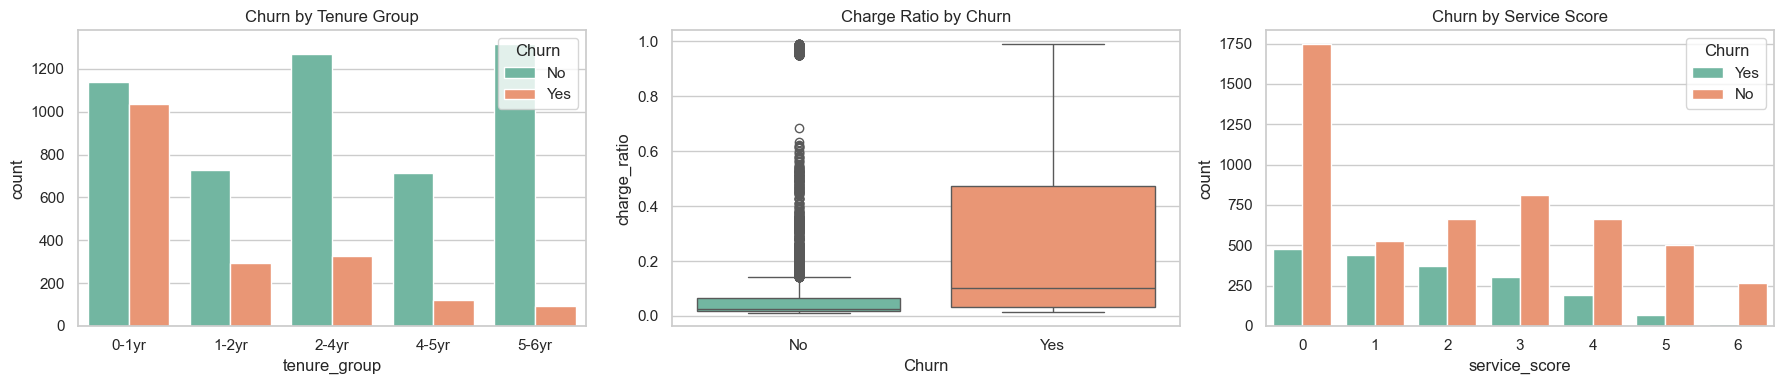

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Tenure group vs churn
sns.countplot(data=df, x='tenure_group', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Tenure Group')

# Charge ratio vs churn
sns.boxplot(data=df, x='Churn', y='charge_ratio', ax=axes[1], palette='Set2')
axes[1].set_title('Charge Ratio by Churn')

# Service score vs churn
sns.countplot(data=df, x='service_score', hue='Churn', ax=axes[2], palette='Set2')
axes[2].set_title('Churn by Service Score')

plt.tight_layout()
plt.savefig('../data/new_features.png', dpi=150)
plt.show()


Encode Binary Columns (Yes/No → 1/0)

In [9]:
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'
]

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

for col in binary_cols:
    df[col] = df[col].map(binary_map)

print("Binary encoding done.")
print(df[binary_cols].head())


Binary encoding done.
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


Encode Multi-Category Columns (One-Hot Encoding)

In [10]:
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod', 'tenure_group'
]

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False)

print("One-hot encoding done. Shape:", df.shape)
print("Columns:", df.columns.tolist())


One-hot encoding done. Shape: (7043, 48)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'charge_ratio', 'service_score', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 

Check Final Dataset

In [11]:
print("Final Shape:", df.shape)
print("\nData Types:\n", df.dtypes.value_counts())
print("\nAny nulls?\n", df.isnull().sum().sum())
print("\nTarget distribution:\n", df['Churn'].value_counts())


Final Shape: (7043, 48)

Data Types:
 bool       36
int64       9
float64     3
Name: count, dtype: int64

Any nulls?
 0

Target distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


Correlation of New Features with Churn

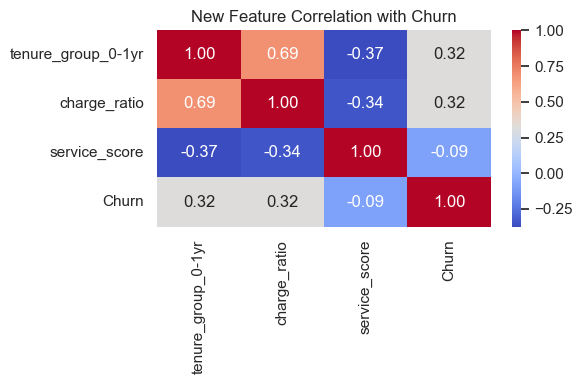

In [12]:
# Check how well our new engineered features correlate with churn
new_feature_corr = df[['tenure_group_0-1yr', 'charge_ratio',
                         'service_score', 'Churn']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(new_feature_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('New Feature Correlation with Churn')
plt.tight_layout()
plt.savefig('../data/new_feature_correlation.png', dpi=150)
plt.show()


Save Processed Data

In [13]:
df.to_csv('../data/processed_churn.csv', index=False)
print("Processed data saved!")
print("Final shape:", df.shape)


Processed data saved!
Final shape: (7043, 48)


## Feature Engineering Summary

### Dataset Starting Point
- Raw dataset: **7,043 rows × 21 columns**
- `TotalCharges` was stored as object dtype — contained **11 hidden blank strings**
  that became NaN after forced numeric conversion

### Data Cleaning
- Fixed `TotalCharges` dtype: object → float64
- Imputed **11 missing values** in `TotalCharges` with **median** (safe for skewed data)
- Dropped `customerID` (identifier, zero predictive value) → shape reduced to **(7043, 20)**

### Engineered Features (3 New Features Added → Shape: 7043 × 23)

| Feature | Logic | Insight from Data |
|---|---|---|
| `tenure_group` | Bucketed tenure into 5 lifecycle stages: 0-1yr, 1-2yr, 2-4yr, 4-5yr, 5-6yr | **0-1yr** is the largest group (2,175 customers) and shows highest churn — confirms EDA finding |
| `charge_ratio` | MonthlyCharges / (TotalCharges + 1) | Higher ratio = customer paying more recently vs total history → price shock signal |
| `service_score` | Count of 6 add-on services subscribed (0–6 scale) | **2,219 customers have 0 services** — these are highest churn risk; more services = more "locked in" |

### Tenure Group Distribution
| Group | Count |
|---|---|
| 0-1yr | 2,175 |
| 2-4yr | 1,594 |
| 5-6yr | 1,407 |
| 1-2yr | 1,024 |
| 4-5yr | 832 |

### Service Score Distribution
| Score | Count |
|---|---|
| 0 | 2,219 |
| 1 | 966 |
| 2 | 1,033 |
| 3 | 1,118 |
| 4 | 852 |
| 5 | 571 |
| 6 | 284 |

### Encoding Strategy
- **Binary columns** (Yes/No, Male/Female) → Label encoded to 1/0
  - Columns: gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn
- **Multi-category columns** → One-hot encoded using `pd.get_dummies`
  - Columns: MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
    DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract,
    PaymentMethod, tenure_group

### Final Processed Dataset
- **Shape: 7,043 rows × 48 columns**
- Data types: 36 bool + 9 int64 + 3 float64
- **0 null values** — clean, model-ready
- Target distribution: **5,174 No (73.5%)** / **1,869 Yes (26.5%)** — class imbalance confirmed
